# Subquestion 2: Estimating Examination Probabilities (PBM)
**Objective:** Quantify how the presence of the DQA module alters the distribution of user attention across the two-column layout by estimating the examination probability $P(E)$ for each position using the Position-Based Model (PBM) framework.

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

def set_deterministic_seed(seed=42):
    """Locks down randomness for base Python and NumPy."""
    # 1. Base Python
    random.seed(seed)
    
    # 2. Environment (Dictionary hashing)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. NumPy
    np.random.seed(seed)
    
    print(f"Global deterministic seed set to {seed}.")

# Execute immediately
set_deterministic_seed(42)

plt.rcParams.update({
    'font.size': 16,          # Global standard font size
    'axes.titlesize': 18,     # Title of the plot
    'axes.labelsize': 16,     # X and Y axis labels (e.g., "Row", "Click Percentage")
    'xtick.labelsize': 15,    # The numbers on the X axis
    'ytick.labelsize': 15,    # The numbers on the Y axis
    'legend.fontsize': 15,    # The legend text
    'legend.title_fontsize': 16 # The legend title
})

# Ensure the src module can be imported
sys.path.append(os.path.abspath('..'))
from src.data_preprocessing import get_behavioral_datasets
from src.pbm_estimation import estimate_pbm_examination

# Set publication-ready plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 14})

Global deterministic seed set to 42.


### 1. Calculate Empirical $P(E)$
We load the behavioral datasets and apply the PBM estimation. The estimation normalizes the empirical CTR against the maximum observed CTR, isolating the relative examination bias for each position.

In [3]:
# 1. Load the data (Using the SQ1/SQ2 Three-way merge)
base_imp, dqa_imp = get_behavioral_datasets()

# 2. Estimate Examination Probabilities for the top 10 positions
base_pbm = estimate_pbm_examination(base_imp, max_position=10)
dqa_pbm = estimate_pbm_examination(dqa_imp, max_position=10)

print("Standard Baseline PBM Estimates:")
display(base_pbm.head(5))

print("\nDQA-Present PBM Estimates:")
display(dqa_pbm.head(5))

Downloading/Loading Qilin from HuggingFace...


Partitioning DQA and merging behavioral baseline...
Flattening to impression level...
SQ1/SQ2 Baseline Impressions: 1029300
SQ1/SQ2 DQA-Present Impressions: 27656
Standard Baseline PBM Estimates:


,position,empirical_ctr,examination_prob
0,1.0,0.626923,1.000000
1,2.0,0.375442,0.598864
2,3.0,0.240540,0.383683
3,4.0,0.289921,0.462451
4,5.0,0.258782,0.412782



DQA-Present PBM Estimates:


,position,empirical_ctr,examination_prob
0,1,0.388034,1.000000
1,2,0.271105,0.698663
2,3,0.202283,0.521302
3,4,0.251916,0.649210
4,5,0.233380,0.601443


### 2. Visualizing the Attention Shift
We plot the estimated examination probabilities to visually compare the attention decay between the standard two-column layout and the DQA-present layout.

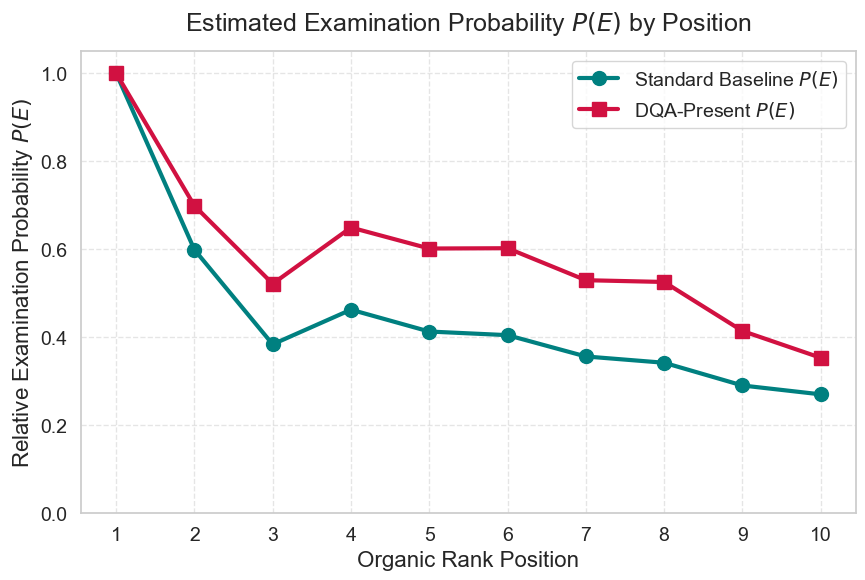

In [4]:
plt.figure(figsize=(10, 6))

# Plot Standard Baseline
plt.plot(base_pbm['position'], base_pbm['examination_prob'], 
         marker='o', markersize=10, linewidth=3, color='#008080', label='Standard Baseline $P(E)$')

# Plot DQA-Present
plt.plot(dqa_pbm['position'], dqa_pbm['examination_prob'], 
         marker='s', markersize=10, linewidth=3, color='#D11141', label='DQA-Present $P(E)$')

# Formatting
plt.title('Estimated Examination Probability $P(E)$ by Position', pad=15, fontsize=18)
plt.xlabel('Organic Rank Position', fontsize=16)
plt.ylabel('Relative Examination Probability $P(E)$', fontsize=16)

plt.xticks(range(1, 11), fontsize=14)
plt.yticks(fontsize=14)

plt.ylim(0, 1.05)
plt.legend(fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('Fig_3 pbm_examination_curves_sq2.pdf', format='pdf', bbox_inches='tight')
plt.show()

### 3. Exporting Bias Parameters
These calculated examination probabilities act as the empirical proof of layout bias. We can export these to use as comparative weights or initialization parameters for our downstream Neural Network (PAL model) in SQ3.

In [5]:
# Create a comparative dataframe
comparison_df = pd.merge(
    base_pbm[['position', 'examination_prob']], 
    dqa_pbm[['position', 'examination_prob']], 
    on='position', 
    suffixes=('_Standard', '_DQA')
)

comparison_df['Absolute_Difference'] = comparison_df['examination_prob_Standard'] - comparison_df['examination_prob_DQA']
comparison_df['Relative_Drop_Pct'] = (comparison_df['Absolute_Difference'] / comparison_df['examination_prob_Standard']) * 100

print("Examination Probability Comparison:")
display(comparison_df.round(4))

# Save the table
comparison_df.to_csv('sq2_pbm_parameters.csv', index=False)

Examination Probability Comparison:


,position,examination_prob_Standard,examination_prob_DQA,Absolute_Difference,Relative_Drop_Pct
0,1.0,1.0000,1.0000,0.0000,0.0000
1,2.0,0.5989,0.6987,-0.0998,-16.6647
2,3.0,0.3837,0.5213,-0.1376,-35.8679
3,4.0,0.4625,0.6492,-0.1868,-40.3846
4,5.0,0.4128,0.6014,-0.1887,-45.7048
5,6.0,0.4045,0.6021,-0.1976,-48.8390
6,7.0,0.3561,0.5294,-0.1733,-48.6715
7,8.0,0.3418,0.5254,-0.1836,-53.7029
8,9.0,0.2902,0.4141,-0.1239,-42.7091
9,10.0,0.2700,0.3532,-0.0832,-30.8076
